In [ ]:
%pip install scikit-learn numpy pandas matplotlib seaborn umap-learn

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import HDBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Data Cleaning

In [3]:
df = pd.read_csv("data/star-galaxy-quasar.csv", comment="#")

# Feature Engineering: Color Indices
df["u_g"] = df["u"] - df["g"]
df["g_r"] = df["g"] - df["r"]
df["r_i"] = df["r"] - df["i"]
df["i_z"] = df["i"] - df["z"]

# Data Cleaning: Remove missing value placeholders (-9999)
df = df[(df[["u", "g", "r", "i", "z"]] > -1000).all(axis=1)]

# Prepare features and labels
X = df.drop(columns=["objid", "class"])
y_true = df["class"]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for Dimensionality Reduction (6 components capture ~95% variance)
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X.shape}")
print(f"PCA shape: {X_pca.shape}")

Original shape: (9985, 12)
PCA shape: (9985, 6)


## HDBScan

In [13]:
# Grid search  

from sklearn.metrics import adjusted_rand_score

best_score = -1
best_params = {}

sample_range = 30 # min_samples: Lower values = less noise
size_range = 80 # min_cluster_size: Lower values = more clusters

for s in range(2,sample_range+1):
    for z in range(20, size_range+1):
        clusterer = HDBSCAN(min_cluster_size=z, min_samples=s, copy=True)
        labels = clusterer.fit_predict(X_pca)
        
        # number of clusters identified
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        # since we have 3 classes, only consider results with 3 clusters
        if n_clusters == 3:
            score = adjusted_rand_score(y_true, labels)
            if score > best_score:
                best_score = score
                best_params = {'min_samples': s, 'min_cluster_size': z, 'ARI': score}

print(f"Best ARI Score: {best_score:.4f}")
print(f"Best Settings: {best_params}")


Best ARI Score: 0.5154
Best Settings: {'min_samples': 4, 'min_cluster_size': 20, 'ARI': 0.5153868225540857}


In [4]:
from sklearn.cluster import HDBSCAN
from sklearn.metrics import adjusted_rand_score

clusterer = HDBSCAN(min_cluster_size=20, min_samples=4) # use best parameters
cluster_labels = clusterer.fit_predict(X_pca)

# Add the results back to original cleaned dataframe 
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"Found {n_clusters} clusters using 6 PC components.")

Found 3 clusters using 6 PC components.


In [5]:
# Cluster value counts
df_clustered['cluster'].value_counts()

cluster
 1    8382
-1    1313
 0     268
 2      22
Name: count, dtype: int64

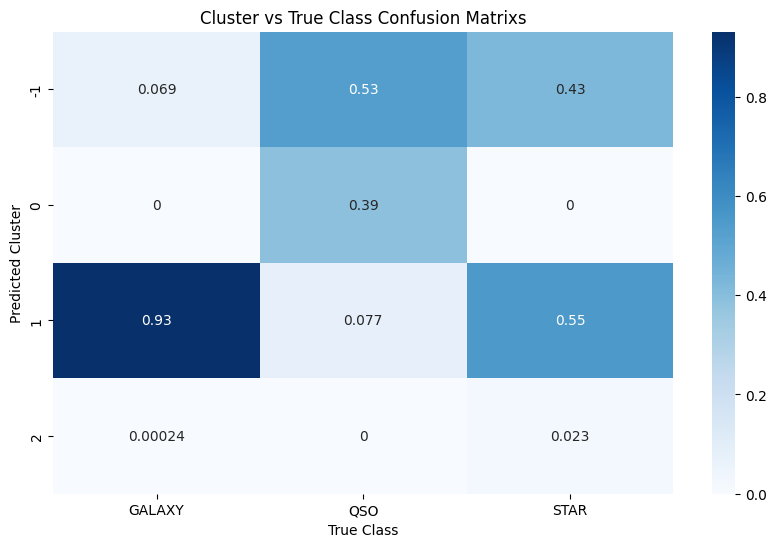

In [10]:
# Contingency Matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(df_clustered['cluster'], y_true, 
                 rownames=['Predicted Cluster'], 
                 colnames=['True Class'],
                 normalize='columns')

plt.figure(figsize=(10, 6))
sns.heatmap(ct, annot=True, cmap='Blues', cbar=True)
plt.title('Cluster vs True Class Confusion Matrixs')
plt.show()


In [7]:
from sklearn.metrics import normalized_mutual_info_score

nmi_score = normalized_mutual_info_score(y_true, cluster_labels)

print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")

Normalized Mutual Information (NMI): 0.3413
